#Tasks

In [1]:
#task-1
# Import libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
data = load_breast_cancer()

X = data.data
y = data.target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature Scaling (Very important for SVM)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# Linear Kernel
# -----------------------------
svm_linear = SVC(kernel='linear', C=1)

svm_linear.fit(X_train, y_train)

y_pred_linear = svm_linear.predict(X_test)

print("===== Linear Kernel =====")
print("Accuracy:", accuracy_score(y_test, y_pred_linear))
print(confusion_matrix(y_test, y_pred_linear))
print(classification_report(y_test, y_pred_linear))

# -----------------------------
# RBF Kernel
# -----------------------------
svm_rbf = SVC(kernel='rbf', C=1, gamma='scale')

svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)

print("\n===== RBF Kernel =====")
print("Accuracy:", accuracy_score(y_test, y_pred_rbf))
print(confusion_matrix(y_test, y_pred_rbf))
print(classification_report(y_test, y_pred_rbf))

===== Linear Kernel =====
Accuracy: 0.9736842105263158
[[41  1]
 [ 2 70]]
              precision    recall  f1-score   support

           0       0.95      0.98      0.96        42
           1       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


===== RBF Kernel =====
Accuracy: 0.9824561403508771
[[41  1]
 [ 1 71]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [2]:
#task-2
# Import libraries
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature Scaling (Important for KNN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Different values of k
k_values = [3, 5, 7]

results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        "k": k,
        "Accuracy": round(accuracy, 4)
    })

# Comparison Table
comparison = pd.DataFrame(results)

print(comparison)

   k  Accuracy
0  3    0.9825
1  5    0.9561
2  7    0.9737


In [3]:
#task-3
# Import libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import pandas as pd

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Create Pipelines
linear_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear', C=1))
])

rbf_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1, gamma='scale'))
])

# Perform 5-Fold Cross Validation
linear_scores = cross_val_score(
    linear_svm,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

rbf_scores = cross_val_score(
    rbf_svm,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

# Comparison Table
results = pd.DataFrame({
    "Model": ["Linear SVM", "RBF SVM"],
    "Mean Accuracy": [
        linear_scores.mean(),
        rbf_scores.mean()
    ],
    "Standard Deviation": [
        linear_scores.std(),
        rbf_scores.std()
    ]
})

print("Cross-validation scores (Linear SVM):")
print(linear_scores)

print("\nCross-validation scores (RBF SVM):")
print(rbf_scores)

print("\nComparison Table:")
print(results)

Cross-validation scores (Linear SVM):
[0.96491228 0.98245614 0.96491228 0.96491228 0.98230088]

Cross-validation scores (RBF SVM):
[0.97368421 0.95614035 1.         0.96491228 0.97345133]

Comparison Table:
        Model  Mean Accuracy  Standard Deviation
0  Linear SVM       0.971899            0.008557
1     RBF SVM       0.973638            0.014679


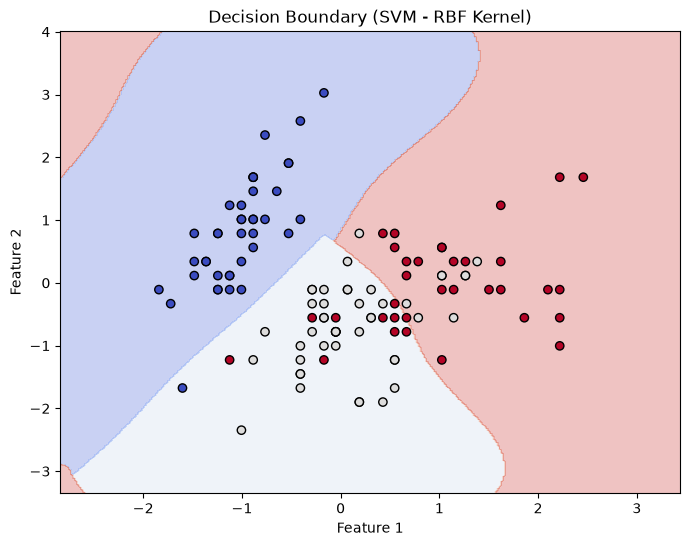

In [4]:
#task-4
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Load dataset
iris = load_iris()

# Use only first two features
X = iris.data[:, :2]
y = iris.target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train SVM
model = SVC(kernel='rbf', gamma='scale', C=1)
model.fit(X_train, y_train)

# Create Mesh Grid
x_min, x_max = X_train[:,0].min()-1, X_train[:,0].max()+1
y_min, y_max = X_train[:,1].min()-1, X_train[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# Predict for every point in mesh
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot Decision Boundary
plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

plt.scatter(
    X_train[:,0],
    X_train[:,1],
    c=y_train,
    edgecolor='k',
    cmap=plt.cm.coolwarm
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision Boundary (SVM - RBF Kernel)")

plt.show()

#Practice Sheet

In [5]:
#practice sheet-1
# Import libraries
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
digits = load_digits()

X = digits.data
y = digits.target

# Use a subset (first 1000 samples)
X = X[:1000]
y = y[:1000]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train KNN Model
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

# Predictions
y_pred = knn.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.985

Confusion Matrix:
[[20  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0]
 [ 0  0 19  1  0  0  0  0  0  0]
 [ 0  0  0 21  0  0  0  0  0  0]
 [ 0  0  0  0 19  0  0  1  0  0]
 [ 0  0  0  0  0 20  0  0  0  0]
 [ 0  0  0  0  0  0 20  0  0  0]
 [ 0  0  0  0  0  0  0 19  0  1]
 [ 0  0  0  0  0  0  0  0 19  0]
 [ 0  0  0  0  0  0  0  0  0 20]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      0.95      0.97        20
           3       0.95      1.00      0.98        21
           4       1.00      0.95      0.97        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       0.95      0.95      0.95        20
           8       1.00      1.00      1.00        19
           9       0.95      1.00      0.98        20

    accuracy  

In [6]:
#practice sheet-2
# Import libraries
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Define SVM models
models = {
    "Linear Kernel": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="linear"))
    ]),

    "Polynomial Kernel": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="poly", degree=3))
    ]),

    "RBF Kernel": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf"))
    ])
}

# Train and evaluate
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results.append({
        "Kernel": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1-Score": round(f1_score(y_test, y_pred), 4)
    })

# Create comparison table
comparison = pd.DataFrame(results)

# Rank by F1-score
comparison = comparison.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

comparison["Rank"] = comparison.index + 1

print(comparison)

              Kernel  Accuracy  Precision  Recall  F1-Score  Rank
0         RBF Kernel    0.9825     0.9861  0.9861    0.9861     1
1      Linear Kernel    0.9737     0.9859  0.9722    0.9790     2
2  Polynomial Kernel    0.9123     0.8780  1.0000    0.9351     3
